<a href="https://colab.research.google.com/github/abdulrahman0700/Industrial_Predictive_Maintenance_Elevvo_internship/blob/main/Notebooks/03_Construct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PACE Stages**

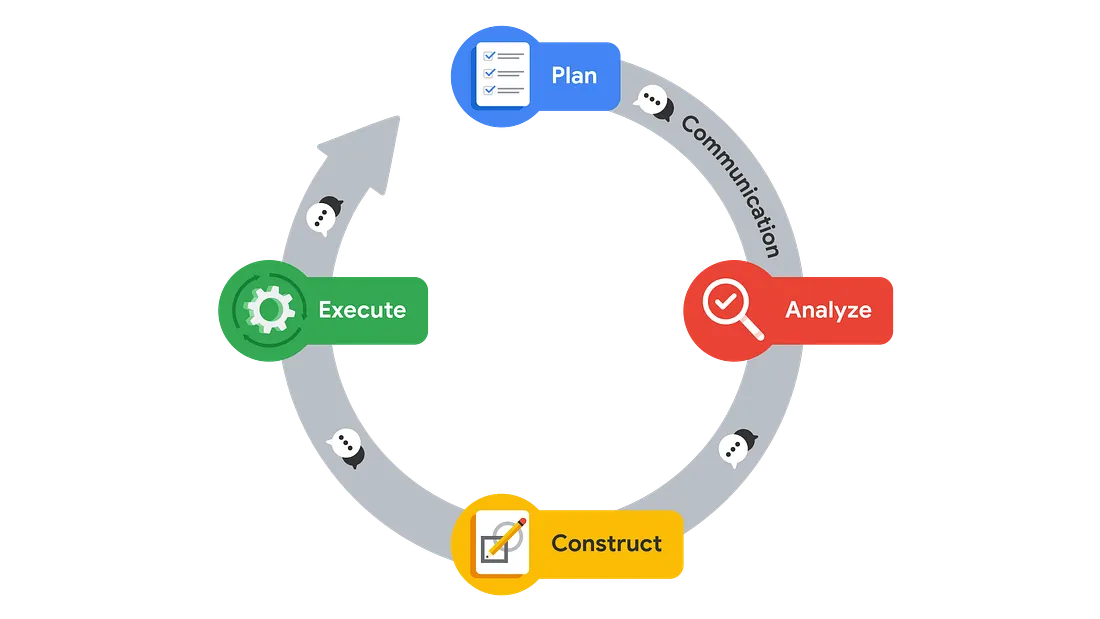

#paCe : Construct Stage

### We can complete this stage by covering these three main topics:

1. Select modeling approach
2. Build models
3. Build machine learning algorithms

### During this stage, Answering the question above by complete the following questions:

1. Identify the prediction task

2. Select the target variable and independent variables.

3. Prepare the data for modeling.

4. Divide the data into training and testing sets.

5. Select appropriate machine-learning algorithms.

6. Train a baseline model.

7. Train and compare multiple candidate models.

8. Check the relevant assumptions for each model.

9. Evaluate the models using suitable performance metrics.

10. Investigate overfitting, underfitting, class imbalance, and data leakage.

11. Improve the best-performing model.

12. Select the final model based on both performance and project requirements.

13. Document the modeling process, results, limitations, resources, and ethical considerations.

14. Save the final model and preprocessing pipeline for the Execute stage.

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder , OneHotEncoder, MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split ,GridSearchCV
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC ,SMOTE
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay , accuracy_score, f1_score , recall_score , precision_score , classification_report
from imblearn.pipeline import Pipeline

In [71]:
df = pd.read_csv("df_cleaned.csv",index_col=0)

In [72]:
df.head(5)

,Product_ID,Type,Air_temperature[K],Process_temperature[K],Rotational_speed[rpm],Torque[Nm],Tool_wear[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Machine_type_Failure
UDI,,,,,,,,,,,,,,
1,L70598,L,297.9,307.1,1525.0,20.3,238,0,0,0,0,0,0,No_Failure
2,H76399,H,298.6,307.8,1384.0,32.3,249,0,0,0,0,0,0,No_Failure
3,M37684,M,305.0,314.1,1958.0,36.3,67,0,0,0,0,0,0,No_Failure
4,L78591,L,300.3,309.7,1046.5,46.8,248,1,0,0,0,1,0,OSF
5,L87722,L,300.7,311.6,1863.0,38.6,133,0,0,0,0,0,0,No_Failure


# Feature Engineering

In [73]:
df['Power[W]'] = round(df['Torque[Nm]'] * (df['Rotational_speed[rpm]'] * (2 * np.pi / 60)),2)
df['strain'] = df['Tool_wear[min]'] * df['Torque[Nm]']
df['Temperature_difference'] = df['Process_temperature[K]'] - df['Air_temperature[K]']

In [74]:
df.sample(10)

,Product_ID,Type,Air_temperature[K],Process_temperature[K],Rotational_speed[rpm],Torque[Nm],Tool_wear[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Machine_type_Failure,Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,,,
304,M24407,M,299.2,308.1,1587.0,31.40,226,0,0,0,0,0,0,No_Failure,5218.37,7096.4,8.9
6513,M71739,M,302.2,313.6,1782.0,38.10,10,0,0,0,0,0,0,No_Failure,7109.86,381.0,11.4
724,M32388,M,302.2,313.1,1359.0,41.00,215,0,0,0,0,0,0,No_Failure,5834.88,8815.0,10.9
9384,L38987,L,297.5,306.8,1261.0,26.60,82,0,0,0,0,0,0,No_Failure,3512.57,2181.2,9.3
1695,L35511,L,300.1,310.2,1404.0,55.30,162,0,0,0,0,0,0,No_Failure,8130.57,8958.6,10.1
6421,H23601,H,297.4,309.1,1549.0,51.30,120,0,0,0,0,0,0,No_Failure,8321.42,6156.0,11.7
5451,L97905,L,300.2,310.5,1731.0,42.90,138,0,0,0,0,0,0,No_Failure,7776.48,5920.2,10.3
9790,L89683,L,298.7,308.6,1571.0,13.35,204,0,0,0,0,0,0,No_Failure,2196.27,2723.4,9.9
9446,L49437,L,297.6,308.9,1545.0,35.10,232,0,0,0,0,0,0,No_Failure,5678.90,8143.2,11.3


In [75]:
df_copy = df.copy()

In [76]:
df_copy.drop(columns=["Product_ID","Tool_Wear_Failure[TWF]","Heat_Dissipation_Failure[HDF]","Power_Failure[PWF]","Overstrain_Failure[OSF]","Random_Failures[RNF]","Machine_type_Failure"],inplace=True)

In [217]:
df_copy.to_csv("df_cleaned_1.csv")

In [77]:
df_copy.head()

,Type,Air_temperature[K],Process_temperature[K],Rotational_speed[rpm],Torque[Nm],Tool_wear[min],Machine_failure,Power[W],strain,Temperature_difference
UDI,,,,,,,,,,
1,L,297.9,307.1,1525.0,20.3,238,0,3241.86,4831.4,9.2
2,H,298.6,307.8,1384.0,32.3,249,0,4681.31,8042.7,9.2
3,M,305.0,314.1,1958.0,36.3,67,0,7443.00,2432.1,9.1
4,L,300.3,309.7,1046.5,46.8,248,1,5128.78,11606.4,9.4
5,L,300.7,311.6,1863.0,38.6,133,0,7530.59,5133.8,10.9


In [91]:
X = df_copy.drop(columns=["Machine_failure"])
y = df_copy["Machine_failure"]

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [98]:
numerical_data = X.select_dtypes(include=np.number)
categorical_data = X.select_dtypes(include="object")

In [99]:
numerical_feature = Pipeline(steps=[
    ("scaler",StandardScaler())
])
categorical_feature = Pipeline(steps=[
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [103]:
Processor = ColumnTransformer(transformers=[
    ("numerical",numerical_feature,numerical_data.columns),
    ("categorical",categorical_feature,categorical_data.columns)
])

In [141]:
models = [LogisticRegression(),RandomForestClassifier(),lgb.LGBMClassifier(),XGBClassifier()]

In [155]:
pipes = [Pipeline(steps=[("processor",Processor),("smote",SMOTE()),("model",model)]) for model in models]


pipes[2]


Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Air_temperature[K]', 'Process_temperature[K]', 'Rotational_speed[rpm]',
       'Torque[Nm]', 'Tool_wear[min]', 'Power[W]', 'strain',
       'Temperature_difference'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('smote', SMOTE()), ('model', LGBMClassifier())])

In [156]:
params=[{"model__multi_class":["multinomial",'ovr','deprecated'],"model__penalty":['l2','l1']},
        {"model__n_estimators":[100,200,300],"model__criterion":['gini','entropy']},
        {"model__boosting_type":['gbdt','goss','dart','rf'],"model__learning_rate":[0.01,0.1,0.001],"model__importance_type":['split','gain']},
        {"model__n_estimators":[100,200,300],"model__learning_rate":[0.01,0.1,0.001],"model__booster":['gbtree','gblinear','dart']}
        ]

In [158]:
grids = [GridSearchCV(estimator=pipes[i],param_grid=params[i],cv=3) for i in range(len(pipes))]

for i in range(len(grids)):
    grids[i].fit(X_train,y_train)

    print(f"model {i} has {grids[i].best_score_}")

model 0 has 0.8160008224778355
model 1 has 0.9696248115272162
[LightGBM] [Info] Number of positive: 4999, number of negative: 4999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 4999, number of negative: 4999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 11
[LightGBM] [Info]

In [207]:
accuracy_result = grids[3].score(X_test,y_test)
accuracy_result

0.9715

In [208]:
predict = grids[3].predict(X_test)

In [209]:
f1_score(y_test,predict)

0.7942238267148014

In [210]:
recall_score(y_test,predict)

0.8029197080291971

In [211]:
precision_score(y_test,predict)

0.7857142857142857

In [212]:
accuracy_score(y_test,predict)

0.9715

In [213]:
tn, fp, fn, tp = confusion_matrix(y_test, predict).ravel()

# The most important is Minimizing False Discovery Rate (FDR), not simply maximizing accuracy

In [214]:
# FDR
FDR = fp / (fp + tp)
print(f"{round(FDR *100,2)} %")

21.43 %


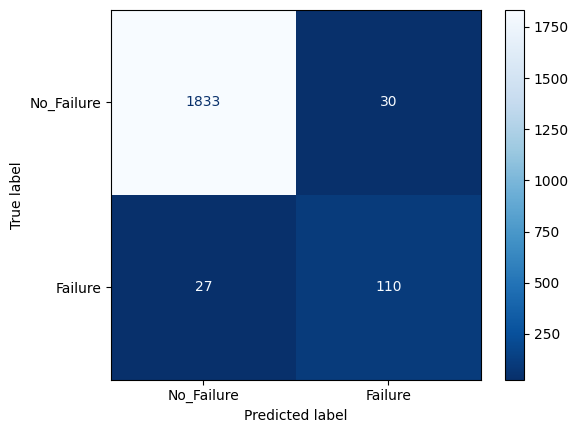

In [215]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predict,
    display_labels=["No_Failure","Failure"],
    cmap=plt.cm.Blues_r
)
plt.show()